## **SUMMARY**
This script is used to create a footprint-level inventory using all nationally-available data sources from Hayward. Steps include addressing within-source and between-source disagreements, imputing and inferring gaps, and exporting to R2D-compatible format. 

### **INPUTS**

NEED TO HAVE RUN: 0_Inventory_Preprocessing.ipynb

NEED TO HAVE RUN: 1_Attribute_to_Ftpt_National.ipynb

No additional inputs needed for this script 


In [1]:
# Copyright (c) 2025, Meredith Lochhead
# All rights reserved.
#
# This source code is licensed under the BSD 3-Clause License found in the
# LICENSE file in the root directory of this source tree.

In [2]:
## NOTE: In order to run this script, a Census API Key is needed
# A Census API Key can be requested at https://www.census.gov/data/developers/about/terms-of-service.html for free by clicking the 'Request a key' banner

# # Option 1: Copy and paste API Key directly
# census_api_key = ""

# Option 2: Import API Key from .txt file
with open("./Input_Data/Census/census_api_key.txt", "r", encoding="utf-8") as file:
    census_api_key = file.read()

In [3]:
# Relevant python functions
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium 
import os 
import sys
from shapely import wkt
import requests

# BRAILS functions for imputation 
from brails.types.image_set import ImageSet    
from brails.types.asset_inventory import Asset, AssetInventory
from brails.utils import Importer

# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)
import functions_national as inv_natl
import functions_inference as infr

In [4]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]

# Set state, state fips, and county for download
state = 'California'
state_fips = '06'
county = 'Alameda'
county_fips = '001'

In [5]:
# Target Directory 
directory = './Inventory_Outputs/Synthesized_National/'
name = 'Synthesized_National'

# Make directory and intermediate directory
os.makedirs(directory, exist_ok=True)
dir_generation = directory + 'InventoryGeneration/'
dir_attribution = directory + 'FootprintAttribution/'
dir_r2d = './R2D_Analysis/Inventories/' + name + '/'
os.makedirs(dir_generation, exist_ok=True)
os.makedirs(dir_r2d, exist_ok=True)


In [6]:
## Set flag to plot data sources for each feature
plot_sources = True 

## **SECTION 1: Select and Prioritize Building Features**

In [7]:
# Load Inventory
inv_raw = inv_natl.json_to_gdf(dir_attribution + 'National_Inventory_Point.json', crs_main)

# Create modifiable instance of raw inventory 
inv_mod = inv_raw.copy()

### **Address Within-Source Disagreement for National Data Sources**

In [8]:
## RESOLVE WITHIN-SOURCE DISAGREEMENT (MINIMAL BETWEEN SOURCE DISAGREEMENT DUE TO USE OF ONlY NATIONAL DATASETS)

# Columns that are modified to a single value (down from a list) by selecting mode 
modified_to_single_solo = ['NSI_BuildingType', 'NSI_MedYearBuilt', 'NSI_NumberOfStories', 'NSI_TotalAreaSqFt']
for col in modified_to_single_solo:
    inv_mod[col + '_Single'] = inv_mod[col].apply(inv_natl.modify_to_single_val)

# Assign paired selections for foundation type and height 
# These variables, since they are directly related, will always be taken from the same original data point
inv_mod[['NSI_FoundationType_Single', 'NSI_FoundationHeight_Single']] = inv_mod[['NSI_FoundationType', 'NSI_FoundationHeight']].apply(inv_natl.modify_to_single_val_paired, axis=1).apply(pd.Series)

# Update occupancy class based on rulesets specific for NSI/HIFLD Occupancy Class 
inv_mod[['NSI_OccupancyClass_Single','NSI_OccupancyClass_MixedUse']] = inv_mod['NSI_OccupancyClass'].apply(inv_natl.modify_to_single_nsi_occupancy).apply(pd.Series)
inv_mod['NSI_OccupancyClass_Single'] = inv_mod['NSI_OccupancyClass_Single'].fillna('')

# Simplify NSI Occupancies Containing RES1 to RES1 
inv_mod.loc[inv_mod['NSI_OccupancyClass_Single'].str.contains('RES1', na=False), 'NSI_OccupancyClass_Single'] = 'RES1'

### **Address Disagreement Between Data Sources**

#### OCCUPANCY CLASS

Occupancy Class Priority List: 

1. Manually-Generated Mobile Home Park Geometries 
2. HIFLD Points (already merged into NSI_OccupancyClass_Single)
3. NSI (already merged into NSI_OccupancyClass_Single)


NOTE: 

IF RUNNING IN A PLACE OTHER THAN HAYWARD, THIS STEP REQUIRES SOME MANUAL DATA GENERATION (SEE INSTRUCTIONS BELOW)


In [9]:
## LOAD HIFLD MOBILE HOME PARK DATA AND CREATE HELPER FILE TO GENERATE POLYGONS
# Load HIFLD Mobile Home Points in Area of Interest
mobile_all = gpd.read_file('./Input_Data/HIFLD/Mobile_Home_Parks.geojson')

# Convert Coordinates
mobile_all = mobile_all.to_crs(epsg=crs_main)

# Assign Census Block and Tract to HIFLD Data
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2010/Hayward_blocks.geojson')
hayward_tracts = gpd.read_file('./Input_Data/Census/Census2010/Hayward_tracts.geojson')
mobile = inv_natl.assign_census_hifld(mobile_all, hayward_blocks, hayward_tracts)

# Convert MH Hayward file geometry to WKT and save as CSV (can be imported)
mobile.to_crs(crs_plot).assign(geometry_wkt=mobile.to_crs(crs_plot).geometry.apply(wkt.dumps)) \
      .drop(columns='geometry') \
      .to_csv('./Input_Data/MH_Manual/Hayward_MH.csv', index=False)

In [10]:
### IF NEEDED, GENERATE MOBILE HOME PARK GEOMETRIES MANUALLY
# Upload the Hayward_MH.csv saved in the above cell as a layer in Google's MyMaps (https://www.google.com/maps/d/). 
# The HIFLD points populated on the map correspond to mobile home parks in the area of interest.
# Set base map to satellite.
# Add a new layer and name it "MH_Polygons"
# Using the "Draw a line" icon under the search bar, draw polygons around each mobile/manufactured home park (not the individual house footprints). The 
# pre-populated HIFLD points can be used as a reference
# Export the newly-generated polygon layer as a csv file for use in the following cell
    # Hover over the three dots next to the layer name (MH_Polygons) and select "Export data" then select "CSV"
    # Move the file to the Input_Data/MH_Manual folder for future use


### USE MANUALLY GENERATED POLYGONS TO FORCE RES2 OCCUPANCY
mh_polygons = gpd.read_file('./Input_Data/MH_Manual/MH_Hayward_Manual_Polygons.csv')
mh_polygons.set_crs(crs_plot, inplace = True)
mh_polygons.to_crs(crs_main, inplace = True)

# Find inventory points that are within RES2 polygons and reset 
# This converts footprints, even that do not currently contain NSI data. Flag is updated to reflect there is now data from a national source 
in_polygons = gpd.sjoin(inv_mod, mh_polygons)
inv_mod.loc[in_polygons.index, 'NSI_OccupancyClass_Single'] = 'RES2'
inv_mod.loc[in_polygons.index, 'National_Flag'] = 1

# Since all data is already integrated into NSI_OccupancyClass_Single, set to be equal to OccupancyClass_Best
inv_mod['OccupancyClass_Best'] = inv_mod['NSI_OccupancyClass_Single']

# Modify so RES2 are all single unit, single story structures (assumed based on spot checking google maps) 
inv_mod.loc[inv_mod['OccupancyClass_Best'].str.contains('RES2', na=False), 'NSI_MinResUnits'] = 1
inv_mod.loc[inv_mod['OccupancyClass_Best'].str.contains('RES2', na=False), 'NSI_MaxResUnits'] = 1
inv_mod.loc[inv_mod['OccupancyClass_Best'].str.contains('RES2', na=False), 'NSI_NumberOfStories_Single'] = 1


In [11]:
# ### UNCOMMENT TO PLOT GEOMETRIES OF MOBILE HOME PARKS AND POINTS CONVERTED TO RES2

# # Create a base map
# m = folium.Map(location=[mh_polygons.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, mh_polygons.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(mh_polygons.copy().to_crs(crs_plot)).add_to(m)

# for idx, row in inv_mod.loc[in_polygons.index].copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red').add_to(m)

# display(m)

#### NUMBER OF UNITS

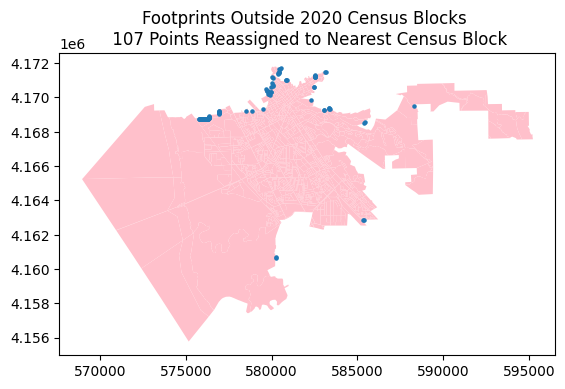

In [12]:
## LINK TO 2020 CENSUS BLOCKS TO ENABLE UNIT SCALING BASED ON DECENNIAL CENSUS DATA 

# Load footprint-based inventory and 2020 Census Blocks 
inventory = inv_mod.copy()
inv_length = len(inventory)
hayward_blocks20 = gpd.read_file('./Input_Data/Census/Census2020/Hayward_blocks.geojson')

# Find corresponding 2020 Census Block 
inventory = inventory.sjoin(hayward_blocks20[['GEOID20','geometry']], how='left')
inventory = inventory.rename(columns = {'GEOID20':'CensusBlock_2020'})

# Filter inventory for footprints with NSI points 
inventory0 = inventory[inventory['National_Flag']==0]
inventory = inventory[inventory['National_Flag']==1]

# Filter inventory for footprints that are outside vs inside 2020 census blocks 
inventory_outside2020blocks = inventory[inventory['CensusBlock_2020'].isna()].copy()

# Plot points
fig, ax = plt.subplots()
hayward_blocks20.plot(ax=ax, color='pink')
inventory_outside2020blocks.plot(ax=ax, markersize = 5)
ax.set_title(f'Footprints Outside 2020 Census Blocks \n {len(inventory_outside2020blocks)} Points Reassigned to Nearest Census Block')
plt.show()

# Assign footprints outside of census block to nearest census block 
inventory_outside2020blocks['Nearest'] = inventory_outside2020blocks['geometry'].apply(lambda point: inv_natl.outside_ftpt_nearest_cb(point, hayward_blocks20.to_crs(crs_main)[['GEOID20','geometry']]))
inventory.loc[inventory_outside2020blocks.index, 'CensusBlock_2020'] = inventory_outside2020blocks['Nearest'].values


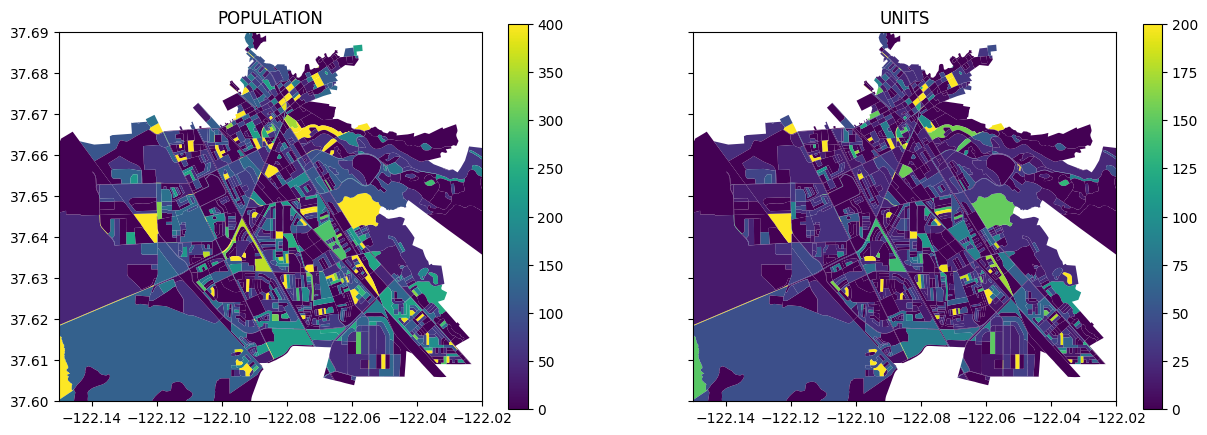

In [13]:
### DOWNLOAD POPULATION AND NUMBER OF UNITS FOR 2020 CENSUS BLOCKS
cbs = inv_natl.download_census_data(census_api_key, hayward_blocks20, state_fips, county_fips)

## PLOT TO MAKE SURE DATA DOWNLOADED FOR CORRECT CENSUS BLOCKS 
merged = cbs.merge(hayward_blocks20, left_on='cb_code', right_on = 'GEOID20')
census_gdf = gpd.GeoDataFrame(merged, geometry=hayward_blocks20.geometry, crs=hayward_blocks20.crs)
fig, ax = plt.subplots(1, 2, figsize = (15, 5), sharex = True, sharey = True)
census_gdf.to_crs(crs_plot).plot(ax =ax[0], column='POP', cmap='viridis', legend=True, vmin = 0, vmax = 400)
census_gdf.to_crs(crs_plot).plot(ax = ax[1], column='UNITS', cmap='viridis', legend=True, vmin = 0, vmax = 200)
ax[0].set_title('POPULATION')
ax[1].set_title('UNITS')
ax[0].set_xlim(xbounds)
ax[0].set_ylim(ybounds)
plt.show()


In [14]:
### ESTIMATE THE NUMBER OF UNITS USING CENSUS INFORMATION AND WITH POPULATION SCALING ###

# Pre-set modification flag to be 0
inventory['Flag_ModifiedByCensus'] = 0
inventory0['Flag_ModifiedByCensus'] = 0

# Assign number of units using information from census block 
inventory2 = inv_natl.assign_units_from_censusblock(inventory.copy(), 'CensusBlock_2020', cbs)

# Re-combine updated inventory with footprints with no NSI points 
inventory = inv_natl.recombine_dropped_data(inventory2, inventory0, inv_length)

# Drop appropriate columns 
inventory = inventory.drop(columns = ['index_right','CensusBlock_2020'])
inv_mod = inventory.copy()

Number of Units Priority List: 

1. Units scaled using 2020 Census data (Units_CensusEstimate)
2. Minimum residential units from NSI points (NSI_MinResUnits) -- this fills in RES values that are not assigned via census scaling. This incldues RES1 (1 unit), RES2 (1 unit), and RES3A (2 units)

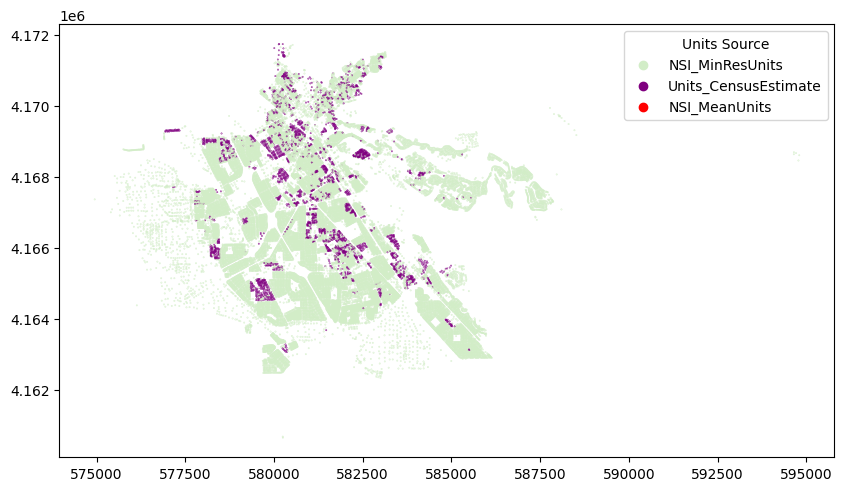

In [15]:
# Assign best value for number of units
inv_mod['Units_Best'] = inv_mod.apply(
    lambda row: (row['Units_CensusEstimate'] if pd.notna(row['Units_CensusEstimate'])
    else (row['NSI_MinResUnits'] if pd.notna(row['NSI_MinResUnits']) 
    else np.nan)), axis=1)

inv_mod['Units_Best_Source'] = inv_mod.apply(
    lambda row: ('Units_CensusEstimate' if pd.notna(row['Units_CensusEstimate'])
    else ('NSI_MinResUnits' if pd.notna(row['NSI_MinResUnits']) 
    else 'None')), axis=1)

# Modulate RES3 Occupancy based on updated number of units 
inv_mod['OccupancyClass_Best'] = inv_mod.apply(infr.update_res_occ, axis=1)


#### PLOT 
if plot_sources: 
    
    ## PLOT INFORMATION SOURCE 
    inv_mod2 = inv_mod[~((inv_mod['National_Flag']==0))].copy()

    # Define a color map based on the unique values in your column
    unique_values = ['NSI_MinResUnits','Units_CensusEstimate', 'NSI_MeanUnits', 'None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'purple', 'red'])}

    # Map colors to the column values
    inv_mod2['color'] = inv_mod2['Units_Best_Source'].map(color_map)

    # Plot the GeoDataFrame
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)

    # Add legend
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Units Source') 

    plt.show()

#### NUMBER OF STORIES

In [16]:
# In the NSI data, there are points with very large number of stories that are unrealistic for Haywrd. This box selects how best to deal with those footprints. 
# The majority of footprints are not adjusted; only those over a user defined threshold will be modified. 

# Set stories limit: Buildings with MORE than this number of stories will be modified 
stories_limit = 12 # Tallest building in Hayward (based on google search) is ~11 stories tall 

# Select which method to use to modify the very tall structures using "reset_very_high_stories"
# Selecting "Mean_of_Occupancy_Class" will reset the number of stories in the footprints exceeding stories_limit to be the mean number of stories for the given occupancy class
# Selecting "Scale_from_Units" will set the number of stories by scaling from the best estimate of the number of units. The average unit is assumed to be 1000 square feet, so estimated stories are computed as (units * 1000) / (footprint area)
# Selecting "No_Reset" does not modify the number of stories relative to the original NSI data 
reset_very_high_stories = 'No_Reset'


if reset_very_high_stories == 'Mean_of_Occupancy_Class':
    inv_mod['Stories_Best'] = inv_natl.reset_very_high_stories_to_mean(inv_mod, stories_limit)

elif reset_very_high_stories == 'Scale_from_Units':
    inv_mod['Stories_Best'] = inv_natl.reset_very_high_stories_by_units(inv_mod, stories_limit)

elif reset_very_high_stories == 'No_Reset':
    inv_mod['Stories_Best'] = inv_mod['NSI_NumberOfStories_Single']

else: 
    raise ValueError('Please Select Valid entry for "reset_very_high_stories"')

#### PLAN AREA

Plan Area Priority List: 

1. NSI Total Area SqFt divided by Stories_Best is highest priority
2. FootprintArea computed off footprint geometry is second. 

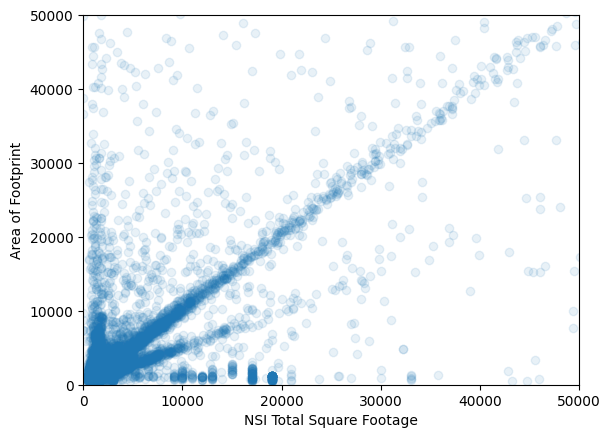

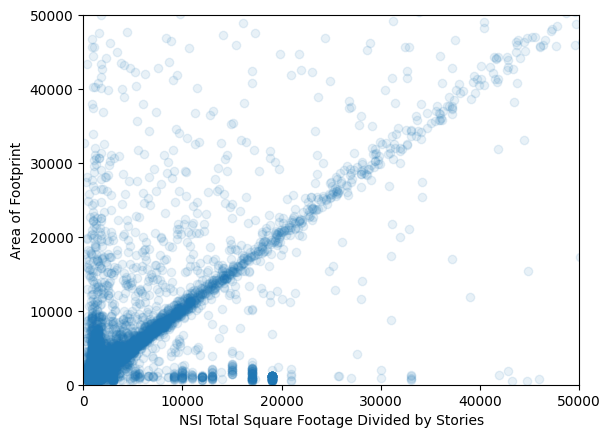

In [17]:
## PLOT TO EXPLORE NSI TOTAL AREA VS SQUARE FOOTAGE OF FOOTPRINT GEOMETRY 

# Plot total square footage 
plt.scatter((inv_mod['NSI_TotalAreaSqFt_Single']), inv_mod['FootprintArea'], alpha = 0.1)
plt.xlim([0,50000])
plt.ylim([0,50000])
plt.xlabel('NSI Total Square Footage')
plt.ylabel('Area of Footprint')
plt.show()

# Plot plan area (total / num floors)  - should be more similar to FootprintArea
plt.scatter((inv_mod['NSI_TotalAreaSqFt_Single']/ inv_mod['Stories_Best']), inv_mod['FootprintArea'], alpha = 0.1)
plt.xlim([0,50000])
plt.ylim([0,50000])
plt.xlabel('NSI Total Square Footage Divided by Stories')
plt.ylabel('Area of Footprint')
plt.show()

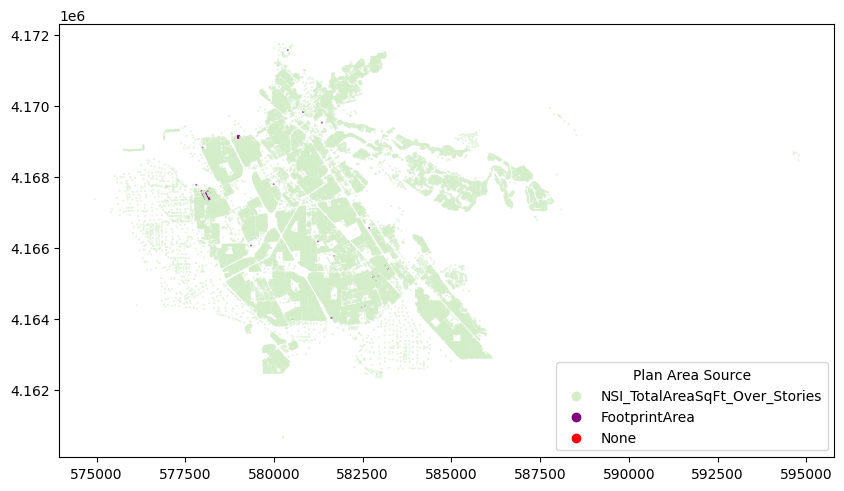

In [18]:
# Assign best value for plan area 
inv_mod['PlanArea_Best'] = inv_mod.apply(
    lambda row: ((row['NSI_TotalAreaSqFt_Single'] / row['Stories_Best']) if (pd.notna(row['NSI_TotalAreaSqFt_Single']) and pd.notna(row['Stories_Best']))
    else (row['FootprintArea'] if pd.notna(row['FootprintArea']) 
    else np.nan)), axis=1)

inv_mod['PlanArea_Best_Source'] = inv_mod.apply(
    lambda row: 'NSI_TotalAreaSqFt_Over_Stories' if pd.notna(row['NSI_TotalAreaSqFt_Single']) and pd.notna(row['Stories_Best'])
    else 'FootprintArea' if pd.notna(row['FootprintArea']) 
    else 'None',
    axis=1)


# Plot sources 
if plot_sources: 

    ## PLOT INFORMATION SOURCE 
    inv_mod2 = inv_mod[~((inv_mod['National_Flag']==0))].copy()

    # Define a color map based on the unique values in your column
    unique_values = ['NSI_TotalAreaSqFt_Over_Stories', 'FootprintArea', 'None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'purple', 'red'])}

    # Map colors to the column values
    inv_mod2['color'] = inv_mod2['PlanArea_Best_Source'].map(color_map)

    # Plot the GeoDataFrame
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)

    # Add legend
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Plan Area Source') 

    plt.show()


#### REPLACEMENT COST

In [19]:
### COMPUTE REPLACEMENT COST USING HAZUS VALUES * SQUARE FOOTAGE 

# Load Hazus cost values 
hazus_conversion = pd.read_csv('./Input_Data/National/Hazus_Cost.csv')

# Compute hazus replacement cost
inv_mod = infr.compute_hazus_replacement_cost(inv_mod.copy(), hazus_conversion)

Text(0.5, 1.0, 'NSI Replacement Cost - Values > $10M')

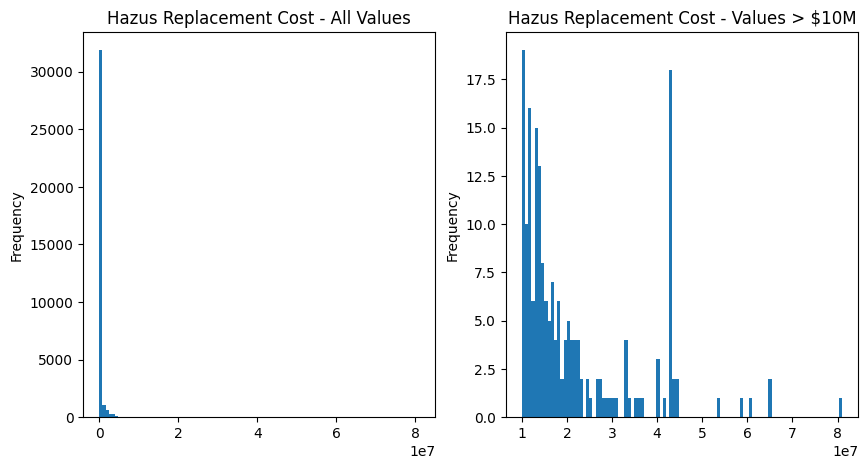

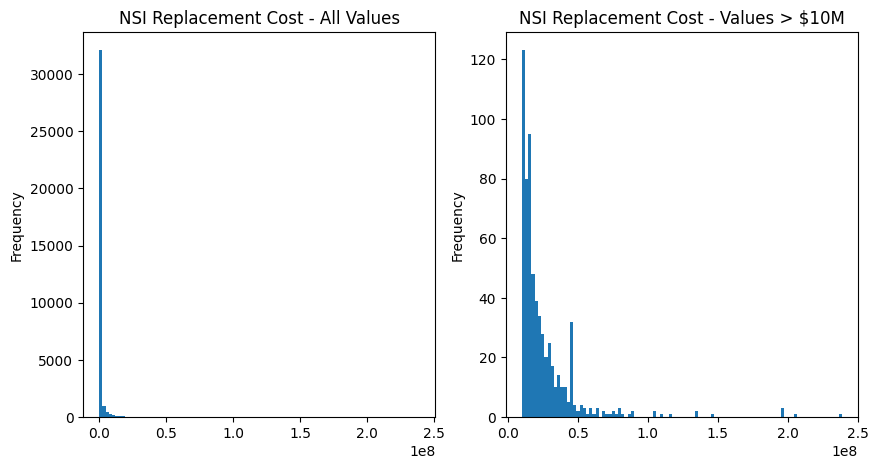

In [20]:
# Check replacement cost for unreasonable values -- Hauzs Replacement Cost
fig, ax = plt.subplots(1,2, figsize=(10, 5)) 
inv_mod['ReplacementCost_Hazus'].plot.hist(ax=ax[0], bins=100)
inv_mod[inv_mod['ReplacementCost_Hazus'] > 1E7]['ReplacementCost_Hazus'].plot.hist(ax=ax[1], bins=100)
ax[0].set_title('Hazus Replacement Cost - All Values')
ax[1].set_title('Hazus Replacement Cost - Values > $10M')

# Check replacement cost for unreasonable values -- NSI Replacement Cost
fig, ax = plt.subplots(1,2, figsize=(10, 5)) 
inv_mod['NSI_ReplacementCost'].plot.hist(ax=ax[0], bins=100)
inv_mod[inv_mod['NSI_ReplacementCost'] > 1E7]['NSI_ReplacementCost'].plot.hist(ax=ax[1], bins=100)
ax[0].set_title('NSI Replacement Cost - All Values')
ax[1].set_title('NSI Replacement Cost - Values > $10M')

# # In case of Hayward, drop Hazus computed values larger than the max of NSI replacement costs MTL 
# # This limit was used in Hayward because of the presence of some unreasonabley large values, and should be further explored 
# highcost = inv_mod[inv_mod['ReplacementCost_Hazus']>max(inv_mod['NSI_ReplacementCost'])]
# highcost.loc[highcost.index, 'ReplacementCost_Hazus'] = np.nan
# print(len(highcost), 'points with NSI replacement cost values larger than the largest Hazus computed value - NSI cost dropped')

Replacement Cost Priority List: 

1. Replacement Cost from summing NSI value present across points (NSI_ReplacementCost)
2. Replacement Cost from multiplying occupancy-specific HAZUS values by total square footage (ReplacementCost_Hazus)

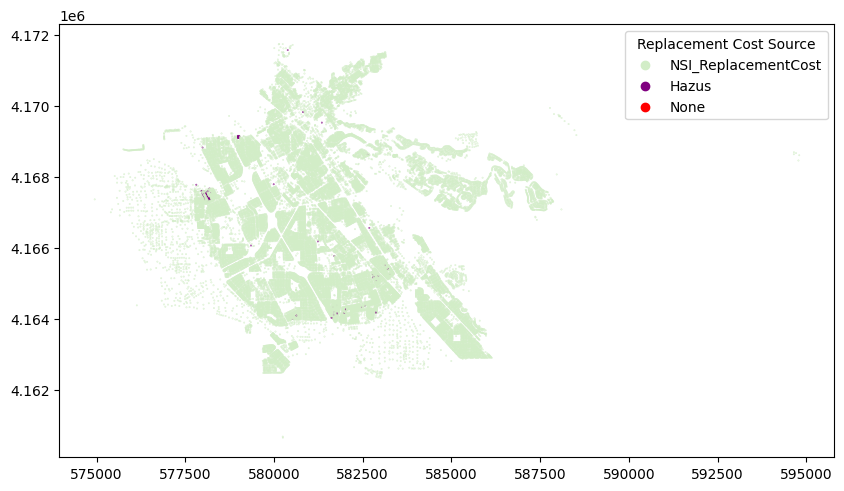

In [21]:
# Remove cases where NSI value is listed as 0
inv_mod.loc[inv_mod[inv_mod['NSI_ReplacementCost'] == 0].index, 'NSI_ReplacementCost'] = np.nan

# Prioritize NSI Replacement Cost, then Hazus-computed replacement cost
inv_mod['ReplacementCost_Best'] = inv_mod.apply(
    lambda row: row['NSI_ReplacementCost'] if pd.notna(row['NSI_ReplacementCost']) 
    else (row['ReplacementCost_Hazus'] if pd.notna(row['ReplacementCost_Hazus']) 
    else (np.nan)), axis=1
)

inv_mod['ReplacementCost_Best_Source'] = inv_mod.apply(
    lambda row: 'NSI_ReplacementCost' if pd.notna(row['NSI_ReplacementCost']) 
    else ('Hazus' if pd.notna(row['ReplacementCost_Hazus']) 
    else ('None')), axis=1
)


#### PLOT 
if plot_sources: 

    ## PLOT INFORMATION SOURCE 
    inv_mod2 = inv_mod[~((inv_mod['National_Flag']==0))].copy()

    # Define a color map based on the unique values in your column
    unique_values = ['NSI_ReplacementCost', 'Hazus', 'None']
    color_map = {value: color for value, color in zip(unique_values, ['#d2edc7', 'purple', 'red'])}

    # Map colors to the column values
    inv_mod2['color'] = inv_mod2['ReplacementCost_Best_Source'].map(color_map)

    # Plot the GeoDataFrame
    fig, ax = plt.subplots(figsize=(10, 8))
    inv_mod2.plot(ax=ax, color=inv_mod2['color'], markersize = .1)

    # Add legend
    for value, color in color_map.items():
        ax.scatter([], [], color=color, label=value)
    ax.legend(title='Replacement Cost Source') 

    plt.show()


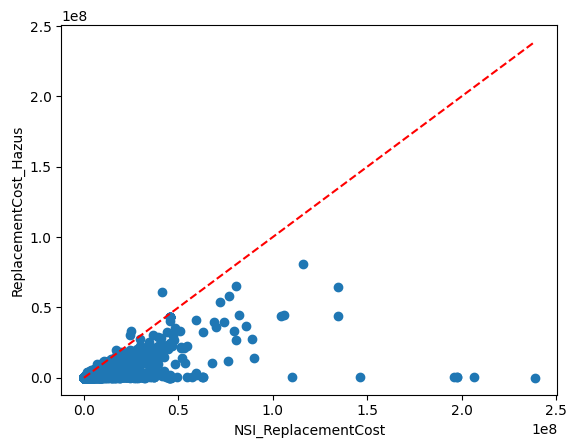

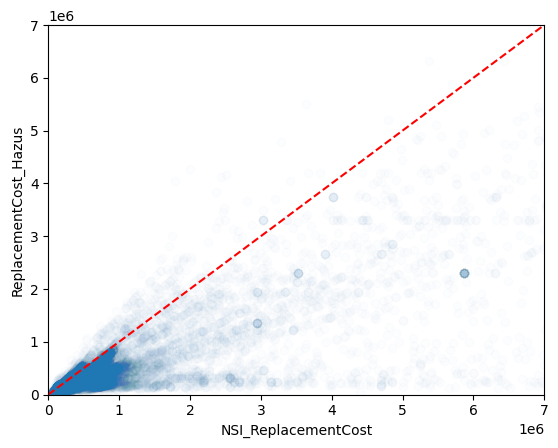

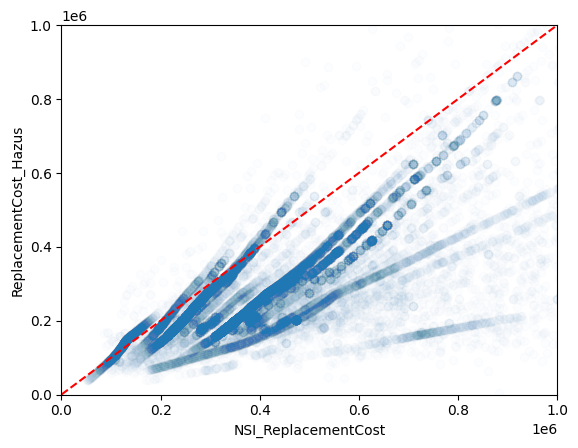

In [22]:
## PLOT TO COMPARE
max_val =  max(inv_mod['NSI_ReplacementCost'].max(), inv_mod['ReplacementCost_Hazus'].max())
min_val = min(inv_mod['NSI_ReplacementCost'].min(), inv_mod['ReplacementCost_Hazus'].min())

for bound in [max_val, 7E6, 1E6]:
    if bound == max_val: 
        plt.scatter(inv_mod['NSI_ReplacementCost'],inv_mod['ReplacementCost_Hazus'], alpha = 1)
        plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='x = y')
    else:
        plt.scatter(inv_mod['NSI_ReplacementCost'],inv_mod['ReplacementCost_Hazus'], alpha = 0.01)
        plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='x = y')
        plt.xlim([0,bound])
        plt.ylim([0,bound])
    plt.xlabel('NSI_ReplacementCost')
    plt.ylabel('ReplacementCost_Hazus')
    plt.show()


### **Export**

In [23]:
# Export Inventory
inv_natl.gdf_to_json(inv_mod, dir_generation + 'Inventory_AllFields.json')

JSON File Saved


## **SECTION 2: Prepare File for Imputation**

In [24]:
# Load national inventory 
data = inv_natl.json_to_gdf(dir_generation + 'Inventory_AllFields.json', crs_main)

# Remove cases of footprints with no data 
data = data[data['National_Flag']==1]

# Convert to format of R2D - keep missing data (for imputation purposes)
for_imputation = data.copy().to_crs(crs_plot)
for_imputation['Longitude'] = for_imputation['geometry'].x
for_imputation['Latitude'] = for_imputation['geometry'].y

# Separate required columns for imputation 
for_imputation = for_imputation[['Latitude','Longitude','PlanArea_Best','ReplacementCost_Hazus','Stories_Best','NSI_MedYearBuilt_Single','ReplacementCost_Best','OccupancyClass_Best', 'NSI_BuildingType_Single','Units_Best','NSI_Population_Night','CensusBlock','CensusTract','FootprintID']]

# Standardize columns for imputation and R2D 
for_imputation = for_imputation.rename(columns={
    'PlanArea_Best' : 'PlanArea',
    'Stories_Best': 'NumberOfStories',
    'NSI_MedYearBuilt_Single': 'YearBuilt',
    'OccupancyClass_Best': 'OccupancyClass',
    'NSI_BuildingType_Single':'BuildingType',
    'ReplacementCost_Best':'ReplacementCost',
    'NSI_Population_Night':'NightPopulation',
    'Units_Best':'NumberOfUnits'})

# Convert None for imputation types 
for_imputation['BuildingType'] = for_imputation['BuildingType'].replace('None', np.nan)

# Add index
for_imputation.insert(0, 'index', range(len(for_imputation)))

# Export inventory 
for_imputation.to_csv(dir_generation + 'Inventory_Before_Imputation.csv', index = False)

## **SECTION 3: Impute Data**

In [25]:
# Specify data for imputation
file_path = dir_generation + 'Inventory_Before_Imputation.csv'

# create an Import to get the classes
importer = Importer()
knn_imputer_class = importer.get_class("KnnImputer")

# Load inventory 
inventory = AssetInventory()
inventory.read_from_csv(file_path,keep_existing=True, id_column='index') 

# Print example of assets 
inventory.get_asset_features(86)[1]  # empty or 'NA' are missing values
# First number is building index, [1] narrows down to just data 

No existing inventory found. Reading in the new inventory from the file.


{'index': 86,
 'PlanArea': 2123.25,
 'ReplacementCost_Hazus': 285725.7525,
 'NumberOfStories': 1.0,
 'YearBuilt': 1984.0,
 'ReplacementCost': 577149.8940000001,
 'OccupancyClass': 'RES3A',
 'BuildingType': 'W',
 'NumberOfUnits': 2.0,
 'NightPopulation': 4.0,
 'CensusBlock': 60014372004006,
 'CensusTract': 6001437200,
 'FootprintID': 92,
 'type': 'building'}

In [26]:
#### IMPUTE DATA USING BRAILS ####
imputer=knn_imputer_class(inventory,n_possible_worlds=1, exclude_features=['PlanArea','ReplacementCost','OccupancyClass','FootprintID','BuildingType','NightPopulation'])
new_inventory = imputer.impute()


# print('\n\nExample Imptued Row Output')
# new_inventory.get_asset_features(86)[1]  # empty or 'NA' are missing values

/Users/mialochhead/Documents/GitHub/Building_Inventory_Generation/inventory_env/lib/python3.10/site-packages/brails/imputers/knn_imputer/knn_imputer.py:158: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bldg_properties_df = bldg_properties_df.replace("", np.nan, inplace=False)


Missing percentages among 34535 assets
NumberOfStories: 0.03%
YearBuilt: 0.30%
Primitive imputation done.
Running the main imputation. This may take a while.
Enumerating clusters: 20 among 70
Enumerating clusters: 40 among 70
Enumerating clusters: 60 among 70
Done imputation. It took 0.00 mins


In [27]:
# Conver to pandas geodataframe
inv_geoj = new_inventory.get_geojson()
gdf = gpd.GeoDataFrame.from_features(inv_geoj["features"])

# Correct data type for population
gdf['NightPopulation'] = gdf['NightPopulation'].replace('',0)

## SAVE IMPUTED INVENTORY
inv_natl.gdf_to_json(gdf, dir_generation + 'Inventory_IMPUTED.json')


/var/folders/h5/xf79vsp167q_tf4t38sfv58c0000gn/T/ipykernel_97328/3198584338.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gdf['NightPopulation'] = gdf['NightPopulation'].replace('',0)


JSON File Saved


## **SECTION 4: Infer Structure Type**

In [28]:
# Load inventory 
data = inv_natl.json_to_gdf(dir_generation + 'Inventory_IMPUTED.json', crs_main)


In [29]:
# SET FLAGS 
use_bldg_type = False # Use building type (material) to constrain list of possible structure types  
allow_mh_only_for_res2 = True # Allows structure type 'MH' only when the occupancy class is RES2 (diverges from Hazus) 
no_urm = True # Doesn't allow the assignment of URM buildings, due to efforts to retrofit those buildings (diverges from Hazus)
res3ab_to_res1_flag = True # Adopts structure types used for 'RES1' to be assigned for RES3A and RES3B. 2-4 unit structures are likely structurally more similar to single family homes than to large apartment buildings. 

# SET VARIABLE NAMES
occ_key = 'OccupancyClass'
nstory_key = 'NumberOfStories'
year_key = 'YearBuilt'
strtype_key = 'StructureType'
bldgtype_key = 'BuildingType'
n_pw = 1

# CALL FUNCTION TO INFER STRUCTURE TYPE
bldg_properties_df = infr.infer_structure_type(data.copy(), state, occ_key, nstory_key, year_key, bldgtype_key, strtype_key, n_pw, use_bldg_type, allow_mh_only_for_res2, no_urm, res3ab_to_res1_flag)

# EXPORT
inv_natl.gdf_to_json(bldg_properties_df, dir_generation + 'Inventory_IMPUTED_With_StructureType.json')


CHECK: Regions considered in structure type assignment: ['West Coast']
HAZUS does not provide structural type information for West Coast-IND2-mid_rise-post_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-COM7-high_rise-1950_to_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-RES6-high_rise-1950_to_1970
Num Buildings in that Class: 1
JSON File Saved


## **SECTION 5: Export for R2D**

In [30]:
# Convert to format of R2D - remove missing data
bldg_properties_df_nomissing = bldg_properties_df[~((bldg_properties_df['StructureType'].isna()) | (bldg_properties_df['StructureType']=='na'))].copy()
print(len(bldg_properties_df[((bldg_properties_df['StructureType'].isna()) | (bldg_properties_df['StructureType']=='na'))].copy()), 'points dropped due to missing structure type')

# Create appropriate columns
r2d = bldg_properties_df_nomissing.copy()
r2d['Longitude'] = r2d['geometry'].x
r2d['Latitude'] = r2d['geometry'].y
r2d = r2d[['Latitude','Longitude','PlanArea','NumberOfStories','YearBuilt','ReplacementCost','ReplacementCost_Hazus','StructureType','BuildingType','OccupancyClass_clean','OccupancyClass', 'NumberOfUnits','NightPopulation','CensusBlock','CensusTract','FootprintID','geometry']]

# Assign design level and height class (used in regional analysis)
r2d = infr.find_design_level(r2d, 'StructureType', 'YearBuilt', 'DesignLevel')
r2d = infr.find_height_class(r2d, 'StructureType', 'NumberOfStories', 'HeightClass')

# Add id
r2d.insert(0, 'id', range(len(r2d)))

# Rename occupancy class columns for R2D use
r2d = r2d.rename(columns={'OccupancyClass': 'OccupancyClass_Actual',
                          'OccupancyClass_clean': 'OccupancyClass'})

# Save inventory
r2d.to_csv(dir_r2d + 'R2D_Inventory.csv', index = False)
inv_natl.gdf_to_json(r2d, dir_r2d + 'R2D_Inventory.json')

# Randomly sample for R2D test run 
sampled_df = r2d.sample(n=50, random_state=1, replace = False)
sampled_df = sampled_df.drop(columns='id')
sampled_df.insert(0, 'id', range(len(sampled_df)))
sampled_df.to_csv(dir_r2d + 'R2D_Inventory_SAMPLED.csv', index = False)


3 points dropped due to missing structure type
JSON File Saved


In [31]:
r2d['NightPopulation'].sum()

np.float64(150779.0)

In [32]:
# #### UNCOMMENT TO CHECK FOR GAPS IN R2D INVENTORY
# # Only BuildingType and HeightClass should possibly have missing data

# for col in r2d.columns: 
#     print(col)
    
#     if len(r2d[r2d[col].isna()]) > 0:
#         print('\n\nDATA WITH ISNA:', col, len(r2d[r2d[col].isna()]),'\n\n')
#     if len(r2d[r2d[col]=='']) > 0:
#         print('\n\nDATA WITH "":',col, len(r2d[r2d[col]=='']),'\n\n')
#     if len(r2d[r2d[col]=='None']) > 0:
#         print('\n\nDATA WITH None:',col, len(r2d[r2d[col]=='']),'\n\n')
#     if len(r2d[r2d[col]=='na']) > 0:
#         print('\n\nDATA WITH na:',col, len(r2d[r2d[col]=='']),'\n\n')

In [33]:
## UNCOMMENT TO CHECK PERCENTAGES OF DATA RELATIVE TO ORIGINAL NSI 

# nsi = inv_natl.json_to_gdf(dir_attribution + 'Intermediate/Hayward_NSI.json', crs_main)
# ftpt_inv = inv_natl.json_to_gdf(dir_generation + 'Inventory_AllFields.json', crs_main)

# print('Percent Change in Night Pop:', (ftpt_inv['NSI_Population_Night'].sum() - nsi['NSI_Population_Night'].sum())/(nsi['NSI_Population_Night'].sum()) * 100)
# print('Percent Change in Day Pop:', (ftpt_inv['NSI_Population_Day'].sum() - nsi['NSI_Population_Day'].sum())/(nsi['NSI_Population_Day'].sum()) * 100, ' - change due to EDU2 populaiton scaling according to HIFLD')
# print('Percent Change in Value:', (ftpt_inv['ReplacementCost_Best'].sum() - nsi['NSI_ReplacementCost'].sum())/(nsi['NSI_ReplacementCost'].sum()) * 100, ' - value lost from GOV1 and other points in roads being dropped, potentially should be dropped?')